<a href="https://colab.research.google.com/github/Banj2/Banj2.github.io/blob/main/Body_Fat_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#BODY FAT

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model, naive_bayes, ensemble ,tree, svm ,model_selection,preprocessing,\
 feature_extraction, metrics, base, pipeline
from joblib import dump,load
import PIL
from IPython.display import display
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Files/bodyfat.csv')
display(df)

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,1.0736,11.0,70,134.25,67.00,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5
248,1.0236,33.6,72,201.00,69.75,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1
249,1.0328,29.3,72,186.75,66.00,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0
250,1.0399,26.0,72,190.75,70.50,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8


In [ ]:
print(f"number of duplicates: {np.sum(df.duplicated())}")

df.drop_duplicates(inplace=True)
print(f"number of duplicates after: {np.sum(df.duplicated())}")

number of duplicates: 0
number of duplicates after: 0


In [ ]:
df.isna().sum()

,0
Density,0
BodyFat,0
Age,0
Weight,0
Height,0
Neck,0
Chest,0
Abdomen,0
Hip,0
Thigh,0


In [ ]:
df.drop(['Neck', 'Chest', 'Abdomen', 'Hip','Thigh','Biceps'], axis = 1, inplace = True)

-

In [ ]:
display(df)

,Density,BodyFat,Age,Weight,Height,Knee,Ankle,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,37.3,21.9,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,37.3,23.4,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,38.9,24.0,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.3,22.8,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,42.2,24.0,27.7,17.7
...,...,...,...,...,...,...,...,...,...
247,1.0736,11.0,70,134.25,67.00,34.8,21.5,25.7,18.5
248,1.0236,33.6,72,201.00,69.75,40.8,23.2,28.6,20.1
249,1.0328,29.3,72,186.75,66.00,37.3,21.5,27.2,18.0
250,1.0399,26.0,72,190.75,70.50,41.6,22.7,29.4,19.8


In [ ]:
display(df)

,Density,BodyFat,Age,Height,Knee,Ankle,Biceps,Forearm,Wrist
0,0.727935,2.587764,23,4.230477,3.645450,3.131137,3.496508,3.346389,2.895912
1,0.734913,1.960095,22,4.293878,3.645450,3.194583,3.449988,3.397858,2.954910
2,0.713636,3.269569,22,4.208417,3.686376,3.218876,3.394508,3.265759,2.867899
3,0.730009,2.433613,26,4.293878,3.645450,3.169686,3.508556,3.414443,2.954910
4,0.710004,3.391147,24,4.280132,3.765840,3.218876,3.502550,3.356897,2.928524
...,...,...,...,...,...,...,...,...,...
247,0.729286,2.484907,70,4.219508,3.577948,3.113515,3.280911,3.284664,2.970414
248,0.704878,3.543854,72,4.259153,3.732896,3.186353,3.589059,3.387774,3.049273
249,0.709414,3.411148,72,4.204693,3.645450,3.113515,3.475067,3.339322,2.944439
250,0.712901,3.295837,72,4.269697,3.751854,3.165475,3.449988,3.414443,3.034953


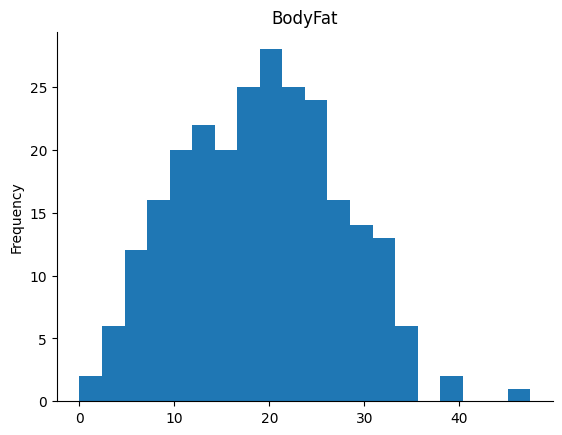

In [ ]:
df['BodyFat'].plot(kind='hist', bins=20, title='BodyFat')
plt.gca().spines[['top', 'right',]].set_visible(False)

though there are some outliers, the highest count of body fats in the data set is in the 3.0 -3.3 range. this tells us that The Body fat of Individuals are more likely to have a 3.0 to 3.3 value.

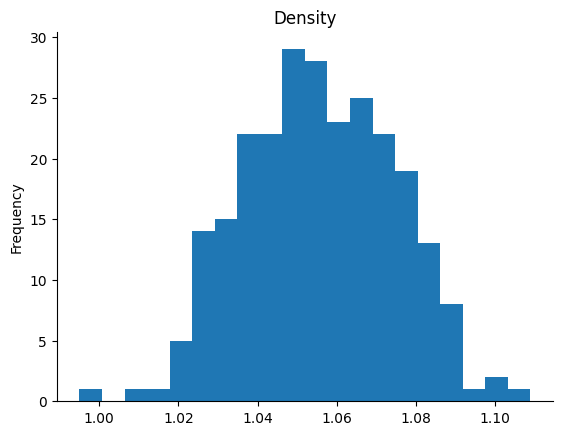

In [ ]:
df['Density'].plot(kind='hist', bins=20, title='Density')
plt.gca().spines[['top', 'right',]].set_visible(False)

based on the graph that is given below, the frequency in which  the values peaked is in 0.72 range. This tells us that the majority of the densities gathered in the dataset are 0.72.

<ipython-input-11-66f229130e45>:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df, x='Age', palette='Blues')


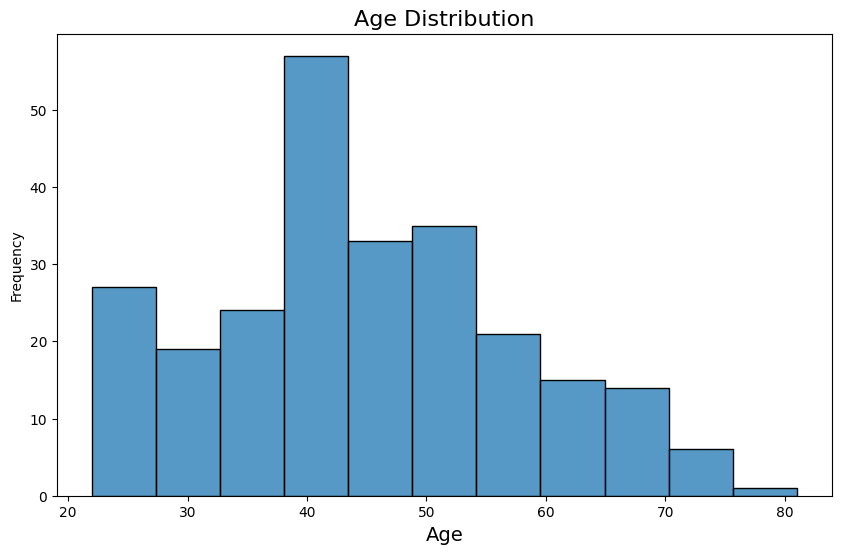

In [ ]:
df['Comment Length'] = df['Age']

plt.figure(figsize=(10, 6))
sns.histplot(df, x='Age', palette='Blues')
plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Frequency')
plt.show()

 the most values in the barplot is in 40. this means that the most people that are in the dataset are probably those near 40 years of age.

<Axes: >

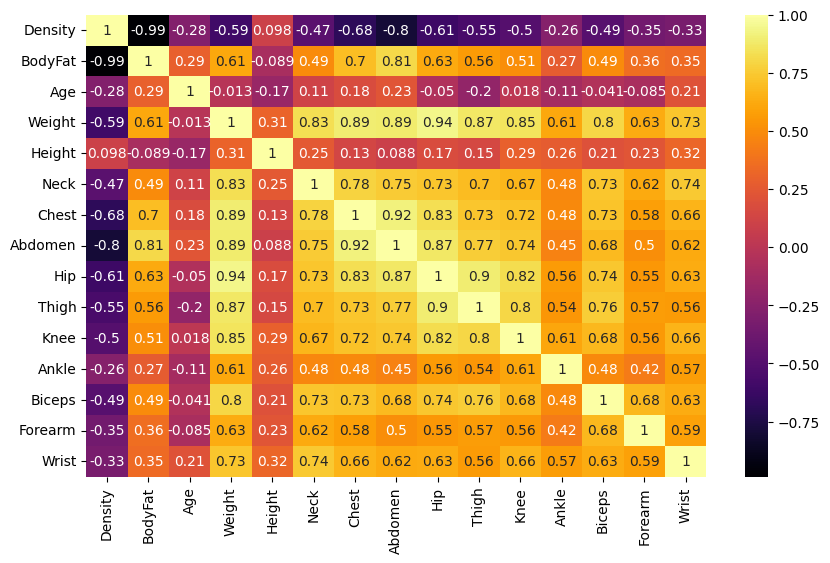

In [ ]:
correlation_matrix = df[df.columns].corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='inferno')

In [ ]:
#'Weight' remove 'Neck', 'Chest', 'Abdomen', 'Hip','Thigh','Biceps'

- in the correlation matrix,  it is observed that there are columns that are significantly Correlated with some other columns, such as the Neck,Chest,Thigh,Abdomen, Hip and Biceps which has many values that are beyond 70%, this means that these coulumns would mimic similar enough effects when compared with some datasets,which would be redundant to the model. these are removed so that `Weight` would represent the columns.

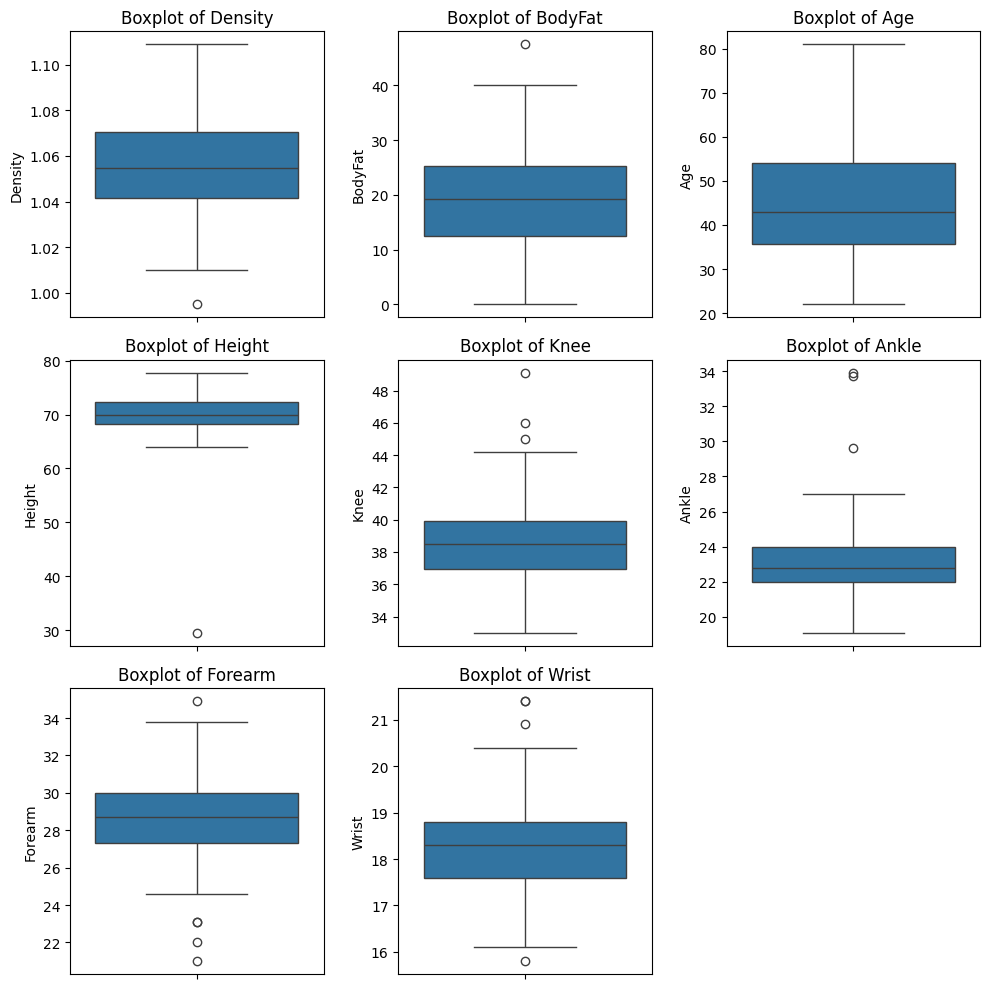

In [ ]:
numeric_columns = ['Density', 'BodyFat', 'Age', 'Height', 'Knee', 'Ankle',
       'Forearm', 'Wrist']

plt.figure(figsize=(10,10))
for i, column in enumerate(numeric_columns, 1):
  plt.subplot(3,3,i)
  sns.boxplot(df[column])
  plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

In [ ]:
df['BodyFat'] = np.log(df['BodyFat'] + 1)
df['Height'] = np.log(df['Height'] + 1)
df['Knee'] = np.log(df['Knee'] + 1)
df['Ankle'] = np.log(df['Ankle'] + 1)
df['Forearm'] = np.log(df['Forearm'] + 1)
df['Wrist'] = np.log(df['Wrist'] + 1)
df['Density'] = np.log(df['Density'] + 1)



In [ ]:
x = df.drop('BodyFat', axis=1)
y = df['BodyFat']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42,)

In [ ]:
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
mse = metrics.mean_squared_error(y_test, y_pred)#mean Squared Error
r2 = metrics.r2_score(y_test, y_pred) #R Squared Value

In [ ]:
import math
#print results
print("Mean Squared Error:",mse)
print("RMSE:",math.sqrt(mse))
print("R-squared:",r2)

#optional: View The coefficients(weights of the Model)
print('Coefficients:',model.coef_)
print('Intercept:',model.intercept_)

Mean Squared Error: 0.0023558943266408787
RMSE: 0.04853755583711317
R-squared: 0.8244105475043247
Coefficients: [-0.14639084  0.0005433  -0.02309601  0.0126151   0.02493737 -0.00732244
  0.00793074  0.00814243  0.0005433 ]
Intercept: 1.3470779699255786


In the Results, it is observed that the RMSE is around 0.04. This means that the model this small percentage of error in the model means that it generates about a 0.04  off the exact mark in its prediction.
 the R sqared that is around 0.90 means that the model is around 82 percent accurate. this small amount of RMSE and a large  r squared tells us that this is a high performing model which can almost accurately predict the exact value with  little error.